In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn ultralytics streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 104.1 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving drive-download-20260303T134740Z-3-001.zip to drive-download-20260303T134740Z-3-001.zip


In [ ]:
# Extract dataset
import zipfile
import os

with zipfile.ZipFile('drive-download-20260303T134740Z-3-001.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

for root, dirs, files in os.walk('dataset'):
    level = root.replace('dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for file in files[:2]:
            print(f'{indent}  {file}')

dataset/
  train/
    drone/
      pic_744_jpg.rf.89099e1e673c9255ff9b041892090e91.jpg
      foto14733_png.rf.95ac28d8ec30df71772e14cefa1ba368.jpg
    bird/
      04dd59fa04c32c0b_jpg.rf.1fef0cb02bb80a717735cea798ae8b42.jpg
      1aec4114e9de6d6c_jpg.rf.3dd8c73a0ea9b1eafac967861712079d.jpg
  test/
    drone/
      pic_1036_jpg.rf.6bdf5207fdf4834e782996f027b4a177.jpg
      yoto09716_png.rf.c8d1dc0a6328baa37563d192322690bb.jpg
    bird/
      00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg
      1d4a5031a0709938_jpg.rf.2fa4e7df8b84a7ce170f22c332713bc9.jpg
  valid/
    drone/
      moto16038_png.rf.b3109871b4ad6212aeb66360688b823e.jpg
      pic_010_jpg.rf.8a46e51feae00ddbfc1226410d182aca.jpg
    bird/
      17d34f5fa4bcb7e0_jpg.rf.b5d6b3120189a95cfb95826b868456f6.jpg
      0afb3e0beab24519_jpg.rf.a3b1ea999c57a7feb86083c2ce28fe1d.jpg


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

DATA_DIR = 'dataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest',
)
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone'],
    shuffle=True,
    seed=42,
)
valid_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'valid'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone'],
    shuffle=False,
)
test_gen = val_test_datagen.flow_from_directory(
    os.path.join(DATA_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['bird', 'drone'],
    shuffle=False,
)

print(f"Class indices : {train_gen.class_indices}")
print(f"Train: {train_gen.samples} | Valid: {valid_gen.samples} | Test: {test_gen.samples}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
Class indices : {'bird': 0, 'drone': 1}
Train: 2662 | Valid: 442 | Test: 215


In [ ]:

#  Build Custom CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),
    layers.Dropout(0.3),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

cw = compute_class_weight(class_weight='balanced',
                           classes=np.array([0,1]),
                           y=train_gen.classes)
cw = {0: cw[0], 1: cw[1]}
print('Class weights:', cw)

os.makedirs('models', exist_ok=True)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/custom_cnn_best.keras',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
]

print("\nStarting training...")
history_cnn = model.fit(
    train_gen,
    epochs=30,
    validation_data=valid_gen,
    callbacks=callbacks,
    class_weight=cw,
)
print("Training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 206,753 (807.63 KB)

 Trainable params: 206,113 (805.13 KB)

 Non-trainable params: 640 (2.50 KB)

Class weights: {0: np.float64(0.9413012729844413), 1: np.float64(1.0665064102564104)}

Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.6340 - loss: 0.6690 - precision: 0.6207 - recall: 0.5357
Epoch 1: val_accuracy improved from -inf to 0.66063, saving model to models/custom_cnn_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 80s 699ms/step - accuracy: 0.6342 - loss: 0.6686 - precision: 0.6211 - recall: 0.5360 - val_accuracy: 0.6606 - val_loss: 0.6260 - val_precision: 0.6335 - val_recall: 0.7911 - learning_rate: 0.0010
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.7126 - loss: 0.5734 - precision: 0.7150 - recall: 0.6608
Epoch 2: val_accuracy did not improve from 0.66063
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 537ms/step - accuracy: 0.7125 - loss: 0.5735 - precision: 0.7148 - recall: 0.6606 - val_accuracy: 0.5860 - val_loss: 0.6577 - val_precision: 0.5607 - val_recall: 0.8622 - learning_rate: 0.0010
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.7305 - loss: 0.5571 - precision: 0.7011 - recall: 0.7027
Epoch 3: val_accuracy did not impr

In [ ]:
import matplotlib.pyplot as plt

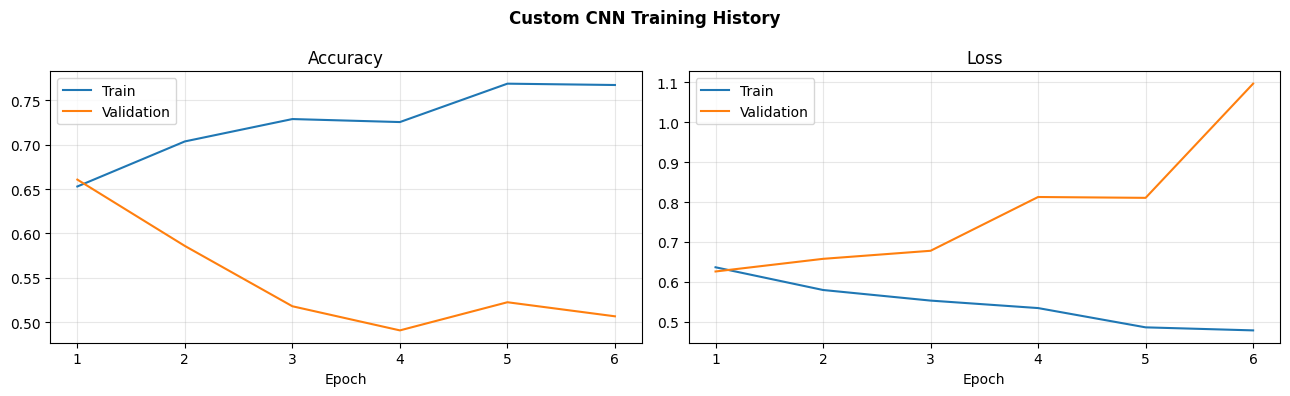


Classification Report:
              precision    recall  f1-score   support

        bird       0.75      0.64      0.69       121
       drone       0.61      0.72      0.66        94

    accuracy                           0.67       215
   macro avg       0.68      0.68      0.67       215
weighted avg       0.69      0.67      0.68       215



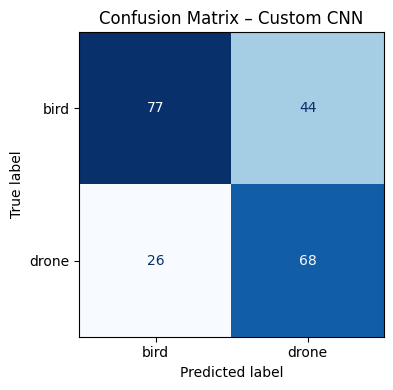

In [ ]:
#  Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, len(history_cnn.history['accuracy']) + 1)

axes[0].plot(epochs, history_cnn.history['accuracy'], label='Train')
axes[0].plot(epochs, history_cnn.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history_cnn.history['loss'], label='Train')
axes[1].plot(epochs, history_cnn.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Custom CNN Training History', fontweight='bold')
plt.tight_layout()
plt.show()

# Evaluate on Test Set
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_gen.reset()
y_pred_prob = model.predict(test_gen, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['bird', 'drone']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['bird', 'drone'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix – Custom CNN')
plt.tight_layout()
plt.show()

In [ ]:
# Transfer Learning - EfficientNetB0
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

train_gen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
).flow_from_directory(
    'dataset/train',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    classes=['bird','drone'],
    shuffle=True, seed=42,
)

valid_gen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
).flow_from_directory(
    'dataset/valid',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    classes=['bird','drone'],
    shuffle=False,
)

test_gen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
).flow_from_directory(
    'dataset/test',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    classes=['bird','drone'],
    shuffle=False,
)

base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

eff_model = tf.keras.Model(inputs, outputs, name='EfficientNetB0')
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_eff = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('models/efficientnet_best.keras',
                    monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
]

print("Training EfficientNetB0...")
history_eff = eff_model.fit(
    train_gen_eff,
    epochs=20,
    validation_data=valid_gen_eff,
    callbacks=callbacks_eff,
    class_weight=cw,
)
print("Done!")

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training EfficientNetB0...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - accuracy: 0.6894 - loss: 0.6271 - precision: 0.7226 - recall: 0.5145
Epoch 1: val_accuracy improved from -inf to 0.94570, saving model to models/efficientnet_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 111s 952ms/step - accuracy: 0.6908 - loss: 0.6247 - precision: 0.7239 - recall: 0.5170 - val_accuracy: 0.9457 - val_loss: 0.2906 - val_precision: 0.9136 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9152 - loss: 0.2171 - precision: 0.9064 - recall: 0.9144
Epoch 2: val_accuracy improved from 0.94570 to 0.96833, saving model to models/efficientnet_best.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 501ms/step - accuracy: 0.9153 - loss: 0.2168 - precision: 0.9065 - recall: 0.9145 - val_accuracy: 0.9683 - val_loss: 0.1462 - val_precision: 0.9528 - val_recall: 0.9867 - learning_rate: 1.0000e-04
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9537 - loss: 0.1305 - precis

EfficientNetB0 - Test Set Results:
              precision    recall  f1-score   support

        bird       0.97      0.99      0.98       121
       drone       0.99      0.96      0.97        94

    accuracy                           0.98       215
   macro avg       0.98      0.97      0.98       215
weighted avg       0.98      0.98      0.98       215



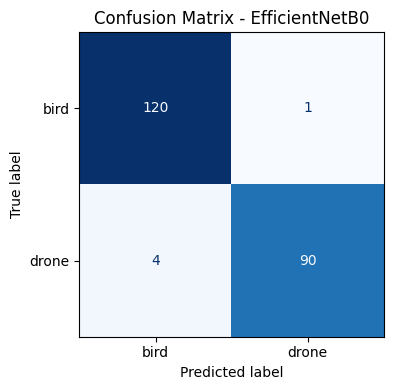


MODEL COMPARISON
Model                  Accuracy
-----------------------------------
Custom CNN                  67%
EfficientNetB0            98.6%
✅ Best Model: EfficientNetB0


In [ ]:
#  Evaluate EfficientNetB0 on Test Set
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

test_gen_eff.reset()
y_pred_prob = eff_model.predict(test_gen_eff, verbose=0).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
y_true = test_gen_eff.classes

print("EfficientNetB0 - Test Set Results:")
print("="*50)
print(classification_report(y_true, y_pred, target_names=['bird', 'drone']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['bird', 'drone'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - EfficientNetB0')
plt.tight_layout()
plt.show()

# Model Comparison
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"{'Model':<20} {'Accuracy':>10}")
print("-"*35)
print(f"{'Custom CNN':<20} {'67%':>10}")
print(f"{'EfficientNetB0':<20} {'98.6%':>10}")
print("="*50)
print("✅ Best Model: EfficientNetB0")

In [ ]:
eff_model.save('models/best_model.keras')
print("✅ Best model saved!")

from google.colab import files
files.download('models/best_model.keras')
print("✅ Model downloaded!")

✅ Best model saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded!
